In [1]:
import sys
sys.path.insert(0,'../build/src/')
import libimp

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


In [2]:
tss = []
dates = []
starts = []
data_path = "../Data/SST/"
ts = np.load(data_path+"mediterranean_sst.npy").astype(np.float64)
date = np.load(data_path+"mediterranean_ts_date.npy")
start_year = np.datetime64(date[0], 'Y').astype(int) + 1970
end_year = np.datetime64(date[-1], 'Y').astype(int) + 1970 
period_starts = []
for year in range(start_year, end_year+1):
    period_starts.append(np.where(date == np.datetime64(str(year) + "-01-01"))[0][0])
    
tss.append(ts)
dates.append(date)
starts.append(period_starts)

data_path = "../Data/climate_pulse/SST/"
df = pd.read_csv(data_path+"2024_era5_daily_series_sst_60S-60N_ocean.csv",skiprows=18)
df = df[df["status"]=="FINAL"]
ts = df["sst"].values.astype(np.float64)
date = df["date"].values.astype(np.datetime64)
date = date[np.where(date <= np.datetime64("2022-12-31"))[0]]
ts = ts[:len(date)]
start_year = np.datetime64(date[0], 'Y').astype(int) + 1970
end_year = np.datetime64(date[-1], 'Y').astype(int) + 1970 
period_starts = []
for year in range(start_year, end_year+1):
    period_starts.append(np.where(date == np.datetime64(str(year) + "-01-01"))[0][0])
    
tss.append(ts)
dates.append(date)
starts.append(period_starts)



data_path_2t = "../Data/climate_pulse/T2M/"
ts = np.load(data_path_2t+"daily_series.npy")
date = np.load(data_path_2t+"daily_series_date.npy")
date = date[np.where(date <= np.datetime64("2022-12-31"))[0]]
ts = ts[:len(date)]
start_year = np.datetime64(date[0], 'Y').astype(int) + 1970
end_year = np.datetime64(date[-1], 'Y').astype(int) + 1970 
period_starts = []
for year in range(start_year, end_year+1):
    period_starts.append(np.where(date == np.datetime64(str(year) + "-01-01"))[0][0])
    
tss.append(ts)
dates.append(date)
starts.append(period_starts)


In [3]:
tss[0]

array([289.01606398, 288.97444983, 288.95906205, ..., 290.83583616,
       290.80429472, 290.7988318 ])

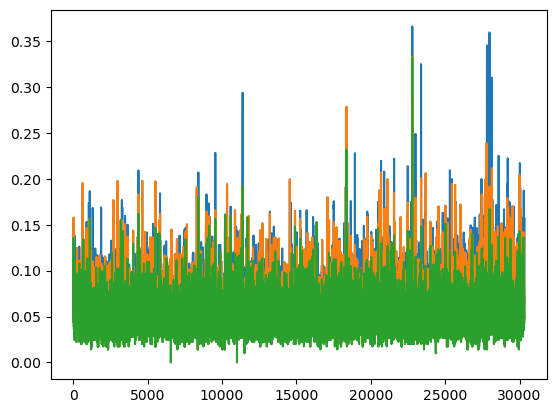

In [4]:
imp0, _ = libimp.BIMP_double(ts, 7, period_starts, 360, 7)
imp1, _ = libimp.BIMP_double(ts, 7, period_starts, 30, 7)
imp2, _ = libimp.BIMP_double(ts, 7, period_starts, 20, 7)

plt.plot(imp2)
plt.plot(imp1)
plt.plot(imp0)

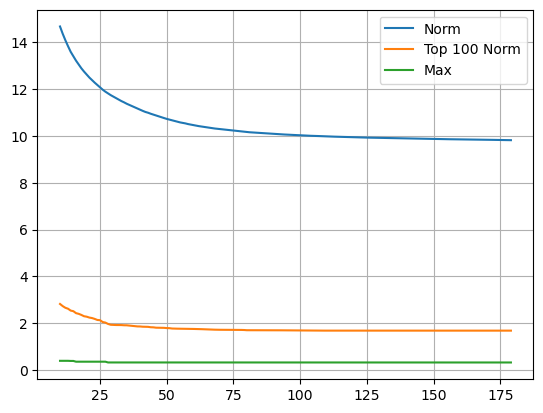

In [5]:
norms = []
maxs = []
top_100s = []
interval_lengths = range(10, 180)
for interval_length in interval_lengths:

    window_size = 7
    exclude = 3
    imp, imp_index = libimp.BIMP_double(ts, window_size, period_starts, interval_length, exclude)

    norms.append(np.linalg.norm(imp))
    maxs.append(np.max(imp))
    top_100 = imp[np.argpartition(imp, -100)[-100:]]
    top_100s.append(np.linalg.norm(top_100))
    
plt.plot(interval_lengths, norms, label="Norm")
plt.plot(interval_lengths, top_100s, label="Top 100 Norm")
plt.plot(interval_lengths, maxs, label="Max")
plt.legend()
plt.grid()
plt.show()

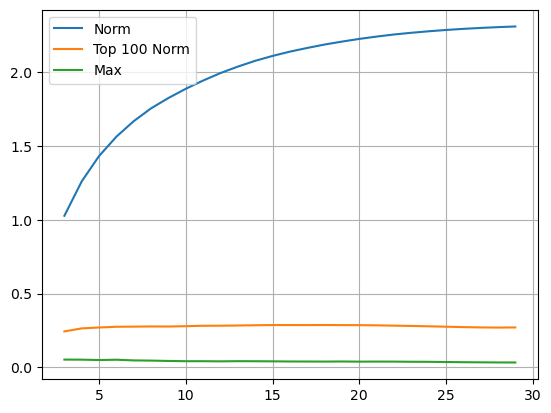

In [6]:
norms = []
maxs = []
top_100s = []
window_sizes = range(3, 30)
for window_size in window_sizes:
    interval_length = 30
    exclude = window_size//2
    imp, imp_index = libimp.BIMP_double(ts, window_size, period_starts, interval_length, exclude)
    imp /= window_size
    norms.append(np.linalg.norm(imp))
    maxs.append(np.max(imp))
    top_100 = imp[np.argpartition(imp, -100)[-100:]]
    top_100s.append(np.linalg.norm(top_100))
    
plt.plot(window_sizes, norms, label="Norm")
plt.plot(window_sizes, top_100s, label="Top 100 Norm")
plt.plot(window_sizes, maxs, label="Max")
plt.legend()
plt.grid()
plt.show()

In [7]:
def stability_score(imp1, imp2):
    """
    Compute the mean absolute percentage difference between two IMP results.
    Lower values indicate greater stability.
    """

    return np.linalg.norm(imp1 - imp2) / np.linalg.norm(imp1)

def rank_correlation(imp1, imp2):
    """
    Compute Spearman's rank correlation coefficient to measure ranking stability.
    """
    return stats.pearsonr(imp1, imp2).correlation

def anomaly_overlap(imp1, imp2, top_p=5):
    """
    Compute Jaccard similarity between the top p% most anomalous subsequences.
    """
    n = len(imp1)
    top_k = int(n * (top_p / 100))  # Compute top-k threshold based on percentage

    # Get indices of top-k anomalies in both IMP results
    top_anomalies1 = set(np.argsort(imp1)[-top_k:])  # Last k are most anomalous
    top_anomalies2 = set(np.argsort(imp2)[-top_k:])

    # Compute Jaccard similarity
    intersection = len(top_anomalies1 & top_anomalies2)
    union = len(top_anomalies1 | top_anomalies2)
    return intersection / union if union > 0 else 0




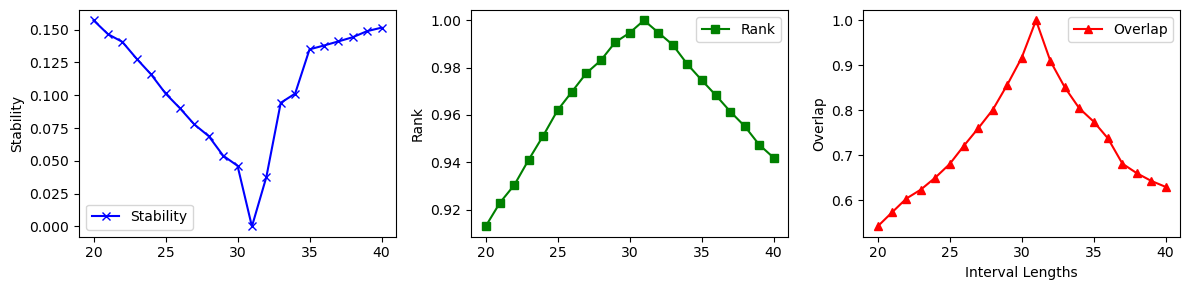

In [8]:
imp_baseline,_ = libimp.BIMP_double(ts, window_size, period_starts, 31, exclude)
imp_baseline = MinMaxScaler(feature_range=(0,1)).fit_transform(imp_baseline.reshape(-1,1)).ravel()


stabilities = []
ranks = []
overlaps = []

interval_lengths = range(20,41)
for interval_length in interval_lengths:
    imp_variation,_ = libimp.BIMP_double(ts, window_size, period_starts, interval_length, exclude)
    imp_variation = MinMaxScaler(feature_range=(0,1)).fit_transform(imp_variation.reshape(-1,1)).ravel()

    stabilities.append(stability_score(imp_baseline, imp_variation))
    ranks.append(rank_correlation(imp_baseline, imp_variation))
    overlaps.append(anomaly_overlap(imp_baseline, imp_variation, top_p=5))

    
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True)  # 3 rows, 1 column

# First plot
axes[0].plot(interval_lengths, stabilities, label="Stability", color='b', marker="x")
axes[0].set_ylabel("Stability")
axes[0].legend()

# Second plot
axes[1].plot(interval_lengths, ranks, label="Rank", color='g', marker="s")
axes[1].set_ylabel("Rank")
axes[1].legend()

# Third plot
axes[2].plot(interval_lengths, overlaps, label="Overlap", color='r', marker="^")
axes[2].set_xlabel("Interval Lengths")
axes[2].set_ylabel("Overlap")
axes[2].legend()

plt.tight_layout()  # Adjust layout for better spacing
plt.show()


In [9]:
imp_baseline - imp_variation

array([-0.04888429, -0.05148436, -0.05340339, ..., -0.06227589,
       -0.06314587, -0.00282785])

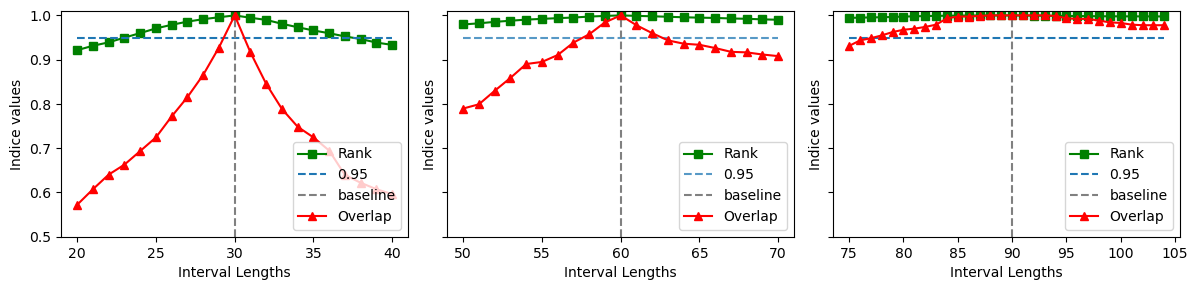

In [10]:

stabilities = []
ranks = []
overlaps = []
interval_lengths = range(20,41)
imp_baseline,_ = libimp.BIMP_double(ts, window_size, period_starts, 30, exclude)
imp_baseline = MinMaxScaler(feature_range=(0,1)).fit_transform(imp_baseline.reshape(-1,1)).ravel()

for interval_length in interval_lengths:
    imp_variation,_ = libimp.BIMP_double(ts, window_size, period_starts, interval_length, exclude)
    imp_variation = MinMaxScaler(feature_range=(0,1)).fit_transform(imp_variation.reshape(-1,1)).ravel()

    stabilities.append(stability_score(imp_baseline, imp_variation))
    ranks.append(rank_correlation(imp_baseline, imp_variation))
    overlaps.append(anomaly_overlap(imp_baseline, imp_variation, top_p=5))

    
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
axes[0].plot(interval_lengths, ranks, label="Rank", color='g', marker="s")
axes[0].hlines(0.95, interval_lengths[0], interval_lengths[-1], label="0.95", ls="dashed")
axes[0].vlines(30, 0.5, 1, label="baseline", ls="dashed", color="gray")
axes[0].set_ylabel("Rank")
axes[0].plot(interval_lengths, overlaps, label="Overlap", color='r', marker="^")
axes[0].set_xlabel("Interval Lengths")
axes[0].set_ylabel("Indice values")
axes[0].set_ylim([0.5,1.01])
axes[0].legend(loc="lower right")

stabilities = []
ranks = []
overlaps = []
interval_lengths = range(50,71)
imp_baseline,_ = libimp.BIMP_double(ts, window_size, period_starts, 60, exclude)
for interval_length in interval_lengths:
    imp_variation,_ = libimp.BIMP_double(ts, window_size, period_starts, interval_length, exclude)
    imp_variation = MinMaxScaler(feature_range=(0,1)).fit_transform(imp_variation.reshape(-1,1)).ravel()

    stabilities.append(stability_score(imp_baseline, imp_variation))
    ranks.append(rank_correlation(imp_baseline, imp_variation))
    overlaps.append(anomaly_overlap(imp_baseline, imp_variation, top_p=5))

axes[1].plot(interval_lengths, ranks, label="Rank", color='g', marker="s")
axes[1].hlines(0.95, interval_lengths[0], interval_lengths[-1], label="0.95", ls="dashed", alpha=0.75)
axes[1].vlines(60, 0.5, 1, label="baseline", ls="dashed", color="gray")
axes[1].set_ylabel("Rank")
axes[1].plot(interval_lengths, overlaps, label="Overlap", color='r', marker="^")
axes[1].set_xlabel("Interval Lengths")
axes[1].set_ylabel("Indice values")
axes[1].set_ylim([0.5,1.01])
axes[1].legend(loc="lower right")

stabilities = []
ranks = []
overlaps = []
interval_lengths = range(75,105)
imp_baseline,_ = libimp.BIMP_double(ts, window_size, period_starts, 90, exclude)
imp_baseline = MinMaxScaler(feature_range=(0,1)).fit_transform(imp_baseline.reshape(-1,1)).ravel()

for interval_length in interval_lengths:
    imp_variation,_ = libimp.BIMP_double(ts, window_size, period_starts, interval_length, exclude)
    imp_variation = MinMaxScaler(feature_range=(0,1)).fit_transform(imp_variation.reshape(-1,1)).ravel()

    stabilities.append(stability_score(imp_baseline, imp_variation))
    ranks.append(rank_correlation(imp_baseline, imp_variation))
    overlaps.append(anomaly_overlap(imp_baseline, imp_variation, top_p=5))

axes[2].plot(interval_lengths, ranks, label="Rank", color='g', marker="s")
axes[2].hlines(0.95, interval_lengths[0], interval_lengths[-1], label="0.95", ls="dashed")
axes[2].vlines(90, 0.5, 1, label="baseline", ls="dashed", color="gray")
axes[2].set_ylabel("Rank")
axes[2].plot(interval_lengths, overlaps, label="Overlap", color='r', marker="^")
axes[2].set_xlabel("Interval Lengths")
axes[2].set_ylabel("Indice values")
axes[2].set_ylim([0.5,1.01])
axes[2].legend(loc="lower right")


plt.tight_layout()
plt.show()

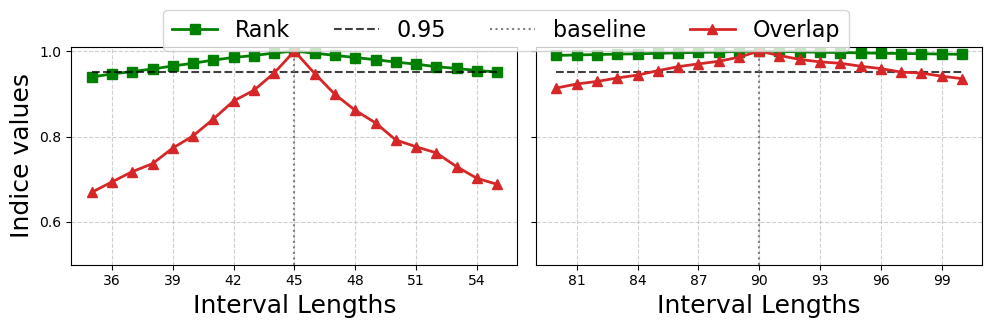

In [11]:
stabilities = []
ranks = []
overlaps = []

window_size = 7
interval_lengths = range(35,56)
imp_baseline,_ = libimp.BIMP_double(ts, window_size, period_starts, 45, exclude)
imp_baseline = MinMaxScaler(feature_range=(0,1)).fit_transform(imp_baseline.reshape(-1,1)).ravel()

for interval_length in interval_lengths:
    imp_variation,_ = libimp.BIMP_double(ts, window_size, period_starts, interval_length, exclude)
    imp_variation = MinMaxScaler(feature_range=(0,1)).fit_transform(imp_variation.reshape(-1,1)).ravel()

    stabilities.append(stability_score(imp_baseline, imp_variation))
    ranks.append(rank_correlation(imp_baseline, imp_variation))
    overlaps.append(anomaly_overlap(imp_baseline, imp_variation, top_p=5))

    
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes[0].plot(interval_lengths, ranks, label="Rank", color='green', marker="s", markersize=7, linestyle='-', linewidth=2)
axes[0].hlines(0.95, interval_lengths[0], interval_lengths[-1], label="0.95", ls="--", color='k', alpha=0.75)
axes[0].vlines(45, 0.5, 1, label="baseline", ls=":", color="gray", linewidth=1.5)
axes[0].set_ylabel("Indice values", fontsize=18)
axes[0].set_xlabel("Interval Lengths", fontsize=18)
axes[0].plot(interval_lengths, overlaps, label="Overlap", color='#d62728', marker="^", markersize=7, linestyle='-', linewidth=2)
axes[0].set_ylim([0.5, 1.01])
#axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle='--', alpha=0.6)

stabilities = []
ranks = []
overlaps = []
interval_lengths = range(80,101)

for interval_length in interval_lengths:
    rank_sum = 0
    jacc_sum = 0
    for i, (ts, period_starts) in enumerate(zip(tss,starts)):
        imp_baseline,_ = libimp.BIMP_double(ts, window_size, period_starts, 90, exclude)
        imp_baseline = MinMaxScaler(feature_range=(0,1)).fit_transform(imp_baseline.reshape(-1,1)).ravel()

        imp_variation,_ = libimp.BIMP_double(ts, window_size, period_starts, interval_length, exclude)
        imp_variation = MinMaxScaler(feature_range=(0,1)).fit_transform(imp_variation.reshape(-1,1)).ravel()

        rank_sum += rank_correlation(imp_baseline, imp_variation)
        jacc_sum += anomaly_overlap(imp_baseline, imp_variation, top_p=5)
    ranks.append(rank_sum / 3)
    overlaps.append(jacc_sum / 3)



axes[1].plot(interval_lengths, ranks, label="Rank", color='green', marker="s", markersize=7, linestyle='-', linewidth=2)
axes[1].hlines(0.95, interval_lengths[0], interval_lengths[-1], label="0.95", ls="--", color='k', alpha=0.75)
axes[1].vlines(90, 0.5, 1, label="baseline", ls=":", color="gray", linewidth=1.5)
axes[1].set_xlabel("Interval Lengths", fontsize=18)
axes[1].plot(interval_lengths, overlaps, label="Overlap", color='#d62728', marker="^", markersize=7, linestyle='-', linewidth=2)
axes[1].set_ylim([0.5, 1.01])
#axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
#axes[2].xaxis.set_major_locator(MaxNLocator(integer=True))



handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.51, 1.11), ncol=4, fontsize=16)

plt.tight_layout(pad=1)
plt.rcParams['font.size'] = 16
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],
})


plt.savefig("L_impact.pdf", format='pdf', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

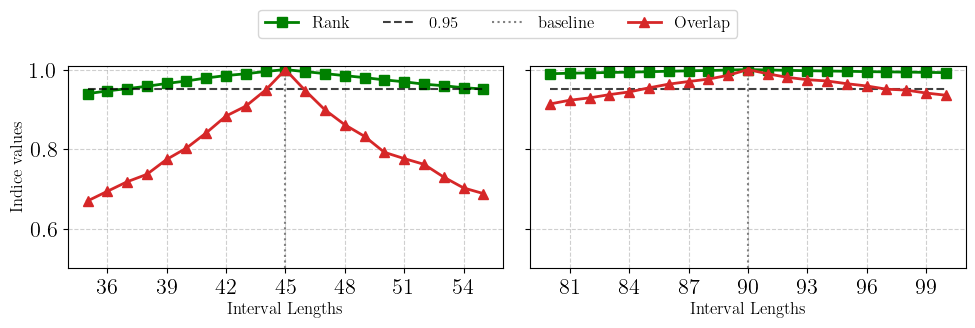

In [12]:
stabilities = []
ranks = []
overlaps = []

window_size = 7
interval_lengths = range(35,56)
imp_baseline,_ = libimp.BIMP_double(ts, window_size, period_starts, 45, exclude)

for interval_length in interval_lengths:
    imp_variation,_ = libimp.BIMP_double(ts, window_size, period_starts, interval_length, exclude)

    stabilities.append(stability_score(imp_baseline, imp_variation))
    ranks.append(rank_correlation(imp_baseline, imp_variation))
    overlaps.append(anomaly_overlap(imp_baseline, imp_variation, top_p=5))

    
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes[0].plot(interval_lengths, ranks, label="Rank", color='green', marker="s", markersize=7, linestyle='-', linewidth=2)
axes[0].hlines(0.95, interval_lengths[0], interval_lengths[-1], label="0.95", ls="--", color='k', alpha=0.75)
axes[0].vlines(45, 0.5, 1, label="baseline", ls=":", color="gray", linewidth=1.5)
axes[0].set_ylabel("Indice values", fontsize=12)
axes[0].set_xlabel("Interval Lengths", fontsize=12)
axes[0].plot(interval_lengths, overlaps, label="Overlap", color='#d62728', marker="^", markersize=7, linestyle='-', linewidth=2)
axes[0].set_ylim([0.5, 1.01])
#axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle='--', alpha=0.6)

stabilities = []
ranks = []
overlaps = []
interval_lengths = range(80,101)

for interval_length in interval_lengths:
    rank_sum = 0
    jacc_sum = 0
    for i, (ts, period_starts) in enumerate(zip(tss,starts)):
        imp_baseline,_ = libimp.BIMP_double(ts, window_size, period_starts, 90, exclude)

        imp_variation,_ = libimp.BIMP_double(ts, window_size, period_starts, interval_length, exclude)

        rank_sum += rank_correlation(imp_baseline, imp_variation)
        jacc_sum += anomaly_overlap(imp_baseline, imp_variation, top_p=5)
    ranks.append(rank_sum / 3)
    overlaps.append(jacc_sum / 3)



axes[1].plot(interval_lengths, ranks, label="Rank", color='green', marker="s", markersize=7, linestyle='-', linewidth=2)
axes[1].hlines(0.95, interval_lengths[0], interval_lengths[-1], label="0.95", ls="--", color='k', alpha=0.75)
axes[1].vlines(90, 0.5, 1, label="baseline", ls=":", color="gray", linewidth=1.5)
#axes[1].set_ylabel("Indice values", fontsize=12)
axes[1].set_xlabel("Interval Lengths", fontsize=12)
axes[1].plot(interval_lengths, overlaps, label="Overlap", color='#d62728', marker="^", markersize=7, linestyle='-', linewidth=2)
axes[1].set_ylim([0.5, 1.01])
#axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
#axes[2].xaxis.set_major_locator(MaxNLocator(integer=True))



handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.51, 1.13), ncol=4, fontsize=12)

plt.tight_layout(pad=1)

plt.rcParams['font.size'] = 14
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],
})


plt.savefig("L_impact.pdf", format='pdf', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [13]:
offset = 10

In [14]:
window_size = 7
interval_length = 90

ranks = []
jaccard = []
for i, (ts, date) in enumerate(zip(tss,dates)):
    print(f"Ts {i}")
    period_starts = []
    start_year = np.datetime64(date[0], 'Y').astype(int) + 1970
    end_year = np.datetime64(date[-1], 'Y').astype(int) + 1970 
    for year in range(start_year, end_year+1):
        period_starts.append(np.where(date == np.datetime64(str(year) + "-01-01"))[0][0])
    
    imp_baseline, _ = libimp.BIMP_double(ts, window_size, period_starts, interval_length, window_size)

    for _ in range(100):
        period_starts_var = []
        start_year = np.datetime64(date[0], 'Y').astype(int) + 1970
        end_year = np.datetime64(date[-1], 'Y').astype(int) + 1970 
      
        for year in range(start_year, end_year+1):
            start = np.where(date == np.datetime64(str(year) + "-01-01"))[0][0]
            if year != start_year:
                period_starts_var.append(start +  np.random.randint(-offset, offset+1))
            else: 
                period_starts_var.append(start)

        imp_variation, _ = libimp.BIMP_double(ts, window_size, period_starts_var, interval_length, window_size)

        ranks.append(rank_correlation(imp_baseline, imp_variation))
        jaccard.append(anomaly_overlap(imp_baseline, imp_variation))

print("Rank Correlation:", np.mean(ranks))
print("Anomaly Overlap (Top 5%):", np.mean(jaccard))

Ts 0
Ts 1
Ts 2
Rank Correlation: 0.9862534862443632
Anomaly Overlap (Top 5%): 0.9350001267893511


In [15]:
window_size = 7
interval_length = 45

ranks = []
jaccard = []
for i, (ts, date) in enumerate(zip(tss,dates)):
    print(f"Ts {i}")
    period_starts = []
    start_year = np.datetime64(date[0], 'Y').astype(int) + 1970
    end_year = np.datetime64(date[-1], 'Y').astype(int) + 1970 
    for year in range(start_year, end_year+1):
        period_starts.append(np.where(date == np.datetime64(str(year) + "-01-01"))[0][0])
    
    imp_baseline, _ = libimp.BIMP_double(ts, window_size, period_starts, interval_length, window_size)

    for _ in range(100):
        period_starts_var = []
        start_year = np.datetime64(date[0], 'Y').astype(int) + 1970
        end_year = np.datetime64(date[-1], 'Y').astype(int) + 1970 
      
        for year in range(start_year, end_year+1):
            start = np.where(date == np.datetime64(str(year) + "-01-01"))[0][0]
            if year != start_year:
                period_starts_var.append(start +  np.random.randint(-offset, offset+1))
            else: 
                period_starts_var.append(start)

        imp_variation, _ = libimp.BIMP_double(ts, window_size, period_starts_var, interval_length, window_size)

        ranks.append(rank_correlation(imp_baseline, imp_variation))
        jaccard.append(anomaly_overlap(imp_baseline, imp_variation))

print("Rank Correlation:", np.mean(ranks))
print("Anomaly Overlap (Top 5%):", np.mean(jaccard))

Ts 0
Ts 1
Ts 2
Rank Correlation: 0.945596915666985
Anomaly Overlap (Top 5%): 0.7763836291631888


[0.7330758499526677, 0.7482675381882071, 0.7700448786361274, 0.7869981658273218, 0.8187346526686589, 0.8387893084793797, 0.8667113318772035, 0.9047166890026208, 0.9280315640777039, 0.9570470888887411, 1.0, 0.9641078658007225, 0.9278275525916427, 0.8956031124177892, 0.8801619972784716, 0.8507681826553682, 0.840351889703118, 0.8248853560809303, 0.8025332686016674, 0.7870095120316257, 0.78111160239329]


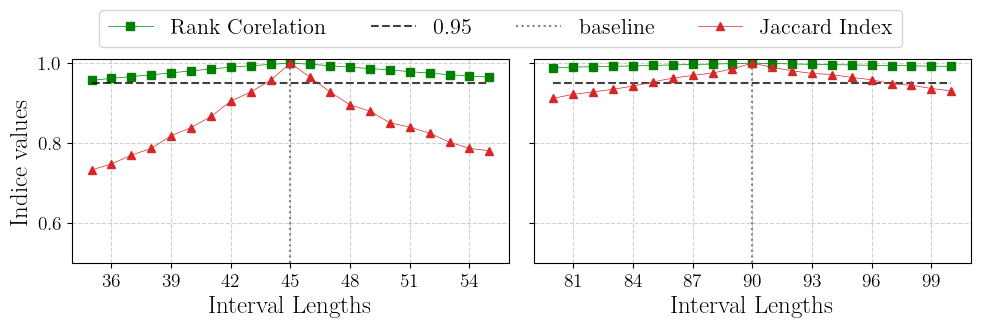

In [16]:
stabilities = []
ranks = []
overlaps = []
e = []

window_size = 7
exclude = 7
interval_lengths = range(35,56)
for interval_length in interval_lengths:
    rank = []
    jacc = []
    for i, (ts, period_starts) in enumerate(zip(tss,starts)):
        imp_baseline,_ = libimp.BIMP_double(ts, window_size, period_starts, 45, exclude)

        imp_variation,_ = libimp.BIMP_double(ts, window_size, period_starts, interval_length, exclude)

        rank.append(rank_correlation(imp_baseline, imp_variation))
        jacc.append(anomaly_overlap(imp_baseline, imp_variation, top_p=5))
    
    ranks.append(np.mean(rank))
    overlaps.append(np.mean(jacc))
    e.append(np.std(jacc))

print(overlaps)
    
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes[0].plot(interval_lengths, ranks, label="Rank Corelation", color='green', marker="s", markersize=6, linestyle='-', linewidth=0.5)
axes[0].hlines(0.95, interval_lengths[0], interval_lengths[-1], label="0.95", ls="--", color='k', alpha=0.75)
axes[0].vlines(45, 0.5, 1, label="baseline", ls=":", color="gray", linewidth=1.5)
axes[0].set_ylabel("Indice values", fontsize=18)
axes[0].set_xlabel("Interval Lengths", fontsize=18)
axes[0].plot(interval_lengths, overlaps, label="Jaccard Index", color='#d62728', marker="^", markersize=6, linestyle='-', linewidth=0.5)
axes[0].set_ylim([0.5, 1.01])
#axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle='--', alpha=0.6)

stabilities = []
ranks = []
e = []
overlaps = []
interval_lengths = range(80,101)

for interval_length in interval_lengths:
    rank = []
    jacc = []
    for i, (ts, period_starts) in enumerate(zip(tss,starts)):
        imp_baseline,_ = libimp.BIMP_double(ts, window_size, period_starts, 90, exclude)

        imp_variation,_ = libimp.BIMP_double(ts, window_size, period_starts, interval_length, exclude)

        rank.append(rank_correlation(imp_baseline, imp_variation))
        jacc.append(anomaly_overlap(imp_baseline, imp_variation, top_p=5))
    
    ranks.append(np.mean(rank))
    overlaps.append(np.mean(jacc))
    e.append(np.std(jacc))


axes[1].plot(interval_lengths, ranks, label="Rank", color='green', marker="s", markersize=6, linestyle='-', linewidth=0.5)
axes[1].hlines(0.95, interval_lengths[0], interval_lengths[-1], label="0.95", ls="--", color='k', alpha=0.75)
axes[1].vlines(90, 0.5, 1, label="baseline", ls=":", color="gray", linewidth=1.5)
axes[1].set_xlabel("Interval Lengths", fontsize=18)
axes[1].plot(interval_lengths, overlaps, label="Jaccard Index", color='#d62728', marker="^", markersize=6, linestyle='-', linewidth=0.5)
axes[1].set_ylim([0.5, 1.01])
#axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
#axes[2].xaxis.set_major_locator(MaxNLocator(integer=True))



handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.51, 1.13), ncol=4, fontsize=16)

plt.tight_layout(pad=1)

plt.rcParams['font.size'] = 16
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],
})


plt.savefig("L_impact_mean.pdf", format='pdf', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

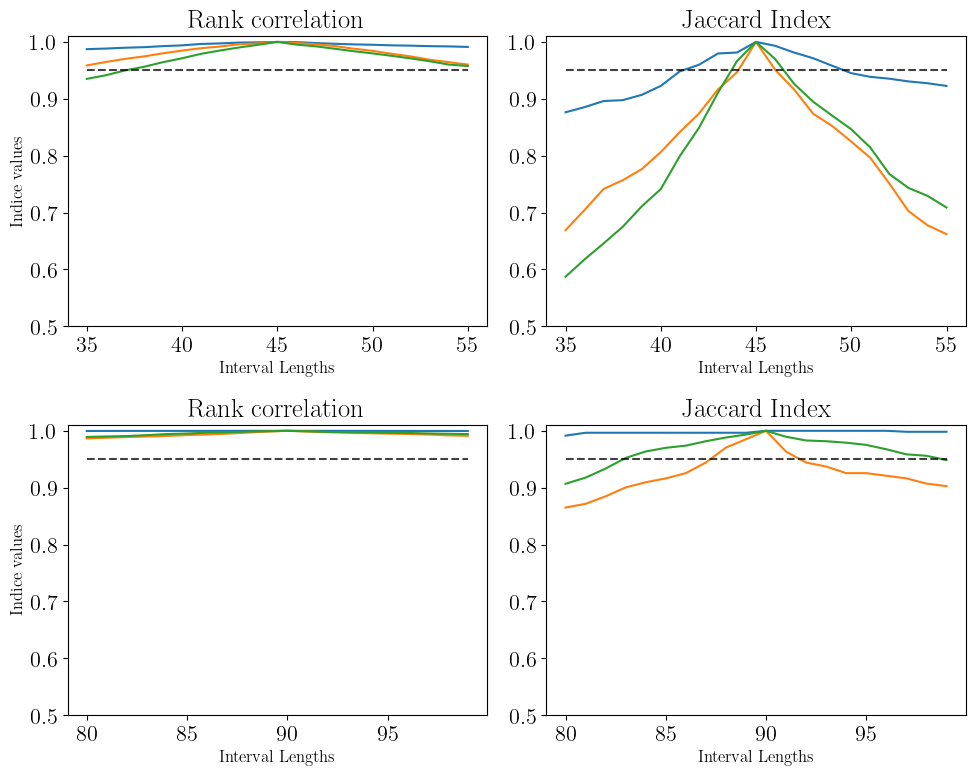

In [17]:
window_size = 14
interval_lengths = range(35,56)
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)

for i, (ts, period_starts) in enumerate(zip(tss,starts)):
    imp_baseline,_ = libimp.BIMP_double(ts, window_size, period_starts, 45, exclude)
    rank = []
    jacc = []

    for interval_length in interval_lengths:

            imp_variation,_ = libimp.BIMP_double(ts, window_size, period_starts, interval_length, exclude)

            rank.append(rank_correlation(imp_baseline, imp_variation))
            jacc.append(anomaly_overlap(imp_baseline, imp_variation, top_p=5))
    
    axes[0,0].plot(interval_lengths, rank)
    axes[0,1].plot(interval_lengths, jacc)

axes[0,0].hlines(0.95, interval_lengths[0], interval_lengths[-1], label="0.95", ls="--", color='k', alpha=0.75)
axes[0,1].hlines(0.95, interval_lengths[0], interval_lengths[-1], label="0.95", ls="--", color='k', alpha=0.75)

axes[0,1].yaxis.set_tick_params(labelleft=True)
axes[0,0].set_ylim([0.5, 1.01])
axes[0,0].set_xlabel("Interval Lengths", fontsize=12)
axes[0,1].set_xlabel("Interval Lengths", fontsize=12)
axes[0,0].set_title("Rank correlation")
axes[0,1].set_title("Jaccard Index")
axes[0,0].set_ylabel("Indice values", fontsize=12)


interval_lengths = range(80,100)

for i, (ts, period_starts) in enumerate(zip(tss,starts)):
    imp_baseline,_ = libimp.BIMP_double(ts, window_size, period_starts, 90, exclude)
    rank = []
    jacc = []

    for interval_length in interval_lengths:

            imp_variation,_ = libimp.BIMP_double(ts, window_size, period_starts, interval_length, exclude)

            rank.append(rank_correlation(imp_baseline, imp_variation))
            jacc.append(anomaly_overlap(imp_baseline, imp_variation, top_p=5))
    
    axes[1,0].plot(interval_lengths, rank)
    axes[1,1].plot(interval_lengths, jacc)

axes[1,0].hlines(0.95, interval_lengths[0], interval_lengths[-1], label="0.95", ls="--", color='k', alpha=0.75)
axes[1,1].hlines(0.95, interval_lengths[0], interval_lengths[-1], label="0.95", ls="--", color='k', alpha=0.75)

axes[1,1].yaxis.set_tick_params(labelleft=True)
axes[1,0].set_ylim([0.5, 1.01])
axes[1,0].set_xlabel("Interval Lengths", fontsize=12)
axes[1,1].set_xlabel("Interval Lengths", fontsize=12)
axes[1,0].set_title("Rank correlation")
axes[1,1].set_title("Jaccard Index")
axes[1,0].set_ylabel("Indice values", fontsize=12)
plt.tight_layout(pad=1)


plt.savefig("L_impact_split.pdf", format='pdf', dpi=300, bbox_inches='tight', pad_inches=0)

plt.show()